---
### 02. 딥러닝 실습
- 앞서 머신러닝에서 실습했던 "광고비에 따른 매출 예측"을 딥러닝 모델로 변경
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

Mounted at /content/drive


In [2]:
# 파이토치 라이브러리
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# Device setting
# device = 'cpu' or 'cuda'로 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# 전처리 1: ML과 동일함
# data loading -> target 분리 -> 검증데이터 분할 -> scaling
df = pd.read_csv('data/advertising.csv')

y = df['Sales']
X = df.drop('Sales', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

In [5]:
# 전처리 2-1: 텐서변환
# 데이터 형태를 numpy array -> tensor로 변환, 타겟은 1차원 -> 2차원으로 변경
X_train_ts = torch.tensor(X_train, dtype=torch.float32)
y_train_ts = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_valid_ts = torch.tensor(X_valid, dtype=torch.float32)
y_valid_ts = torch.tensor(y_valid.values, dtype=torch.float32).view(-1,1)

In [6]:
# 전처리 2-2: 연산에 사용할 디바이스 할당
X_train_ts, y_train_ts = X_train_ts.to(device), y_train_ts.to(device)
X_valid_ts, y_valid_ts = X_valid_ts.to(device), y_valid_ts.to(device)

In [7]:
# 전처리 2-3: 데이터로더 구성
# train 데이터를 텐서데이터세트로 구성 후, 32개 미니배치로 순차적으로 모델에 공급
Batch_size = 32
train_ds = TensorDataset(X_train_ts, y_train_ts)
train_loader = DataLoader(train_ds, batch_size = Batch_size, shuffle=True)

In [9]:
# modeling 1: 1 layer model
in_features = X_train_ts.shape[1] # 입력변수가 3개이므로 3

model = nn.Sequential(
    nn.Linear(in_features, 1),    # 입력변수 3개, 출력(예측) 1개
).to(device)

In [11]:
# modeling 2: loss function, optimizer, learning_rate
loss_fn = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.01)

In [17]:
# training
Epochs = 100
tr_loss_list, valid_loss_list = [], []

# 반복학습 정의
for epoch in range(Epochs):
  model.train()
  total_loss = 0.0
  n_batch = 0

  for X, y in train_loader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    n_batch +=1

  # 오차집계
  tr_loss = total_loss / n_batch

  # 검증
  model.eval()
  with torch.no_grad():
    valid_pred = model(X_valid_ts)
    valid_loss = loss_fn(valid_pred, y_valid_ts).item()

  tr_loss_list.append(tr_loss)
  valid_loss_list.append(valid_loss)

  print(f"Epoch {epoch+1 : 4d} | Train Loss {tr_loss:.4f} | Validation Loss {valid_loss:.4f}")

Epoch    1 | Train Loss 102.9631 | Validation Loss 100.2183
Epoch    2 | Train Loss 102.1372 | Validation Loss 99.3785
Epoch    3 | Train Loss 101.2767 | Validation Loss 98.5510
Epoch    4 | Train Loss 100.4187 | Validation Loss 97.7314
Epoch    5 | Train Loss 99.5825 | Validation Loss 96.9214
Epoch    6 | Train Loss 98.7561 | Validation Loss 96.1182
Epoch    7 | Train Loss 97.9277 | Validation Loss 95.3254
Epoch    8 | Train Loss 97.1080 | Validation Loss 94.5194
Epoch    9 | Train Loss 96.2823 | Validation Loss 93.7402
Epoch   10 | Train Loss 95.4803 | Validation Loss 92.9551
Epoch   11 | Train Loss 94.6795 | Validation Loss 92.1742
Epoch   12 | Train Loss 93.8847 | Validation Loss 91.4049
Epoch   13 | Train Loss 93.0845 | Validation Loss 90.6452
Epoch   14 | Train Loss 92.3044 | Validation Loss 89.8915
Epoch   15 | Train Loss 91.5225 | Validation Loss 89.1320
Epoch   16 | Train Loss 90.7656 | Validation Loss 88.3769
Epoch   17 | Train Loss 89.9767 | Validation Loss 87.6388
Epoch   1

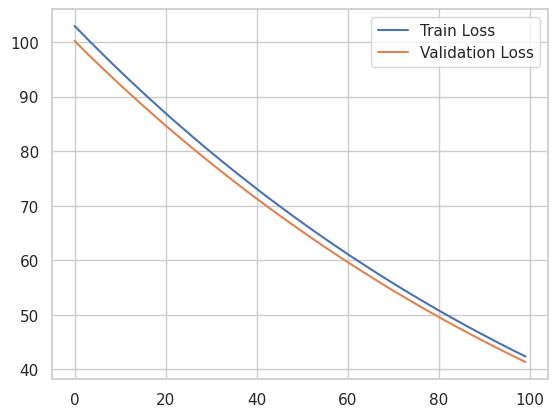

In [18]:
# Learning curve
plt.plot(tr_loss_list, label='Train Loss')
plt.plot(valid_loss_list, label='Validation Loss')
plt.legend()
plt.show()

In [25]:
# 검증
# 참고. 넘파이는 GPU를 지원하지 않음
from sklearn.metrics import *

model.eval()
with torch.no_grad():
  pred_valid = model(X_valid_ts).cpu().numpy()

rmse = root_mean_squared_error(y_valid_ts.cpu().numpy(), pred_valid)
mae = mean_absolute_error(y_valid_ts.cpu().numpy(), pred_valid)
r2 = r2_score(y_valid_ts.cpu().numpy(), pred_valid)

In [26]:
result_df = pd.DataFrame({
    'RMSE': [rmse],
    'MAE': [mae],
    'R2': [r2]
})

result_df

,RMSE,MAE,R2
0,6.429243,6.16664,-0.309584
